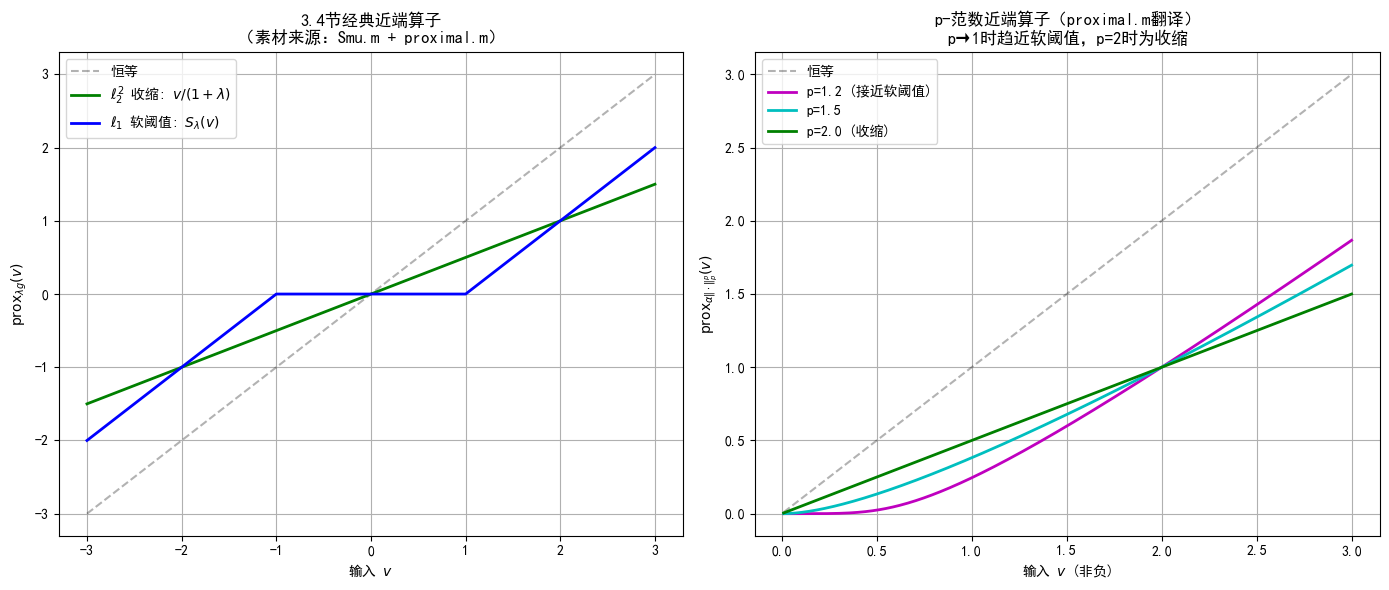

In [1]:
"""
实验3.4 近端算子计算与性质
对应章节：3.4（近端算子定义、软阈值、硬阈值、收缩算子）
素材来源：winter_school/BolognaWinterSchool2023-main/Matlab/proximal.m (Python翻译)
          winter_school/BolognaWinterSchool2023-main/Matlab/Smu.m (Python翻译)
          Mathematics.../CompImLab25.ipynb Part 2 (soft_thresh函数)
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

# ---- 1. 软阈值 S_λ(v)（取自Smu.m的Python翻译）----
def soft_threshold(v, mu):
    """软阈值函数 S_mu(v) = sign(v) * max(|v|-mu, 0)
    翻译自 Smu.m (Daubechies, Defrise and De Mol 2004)
    
    原始Matlab代码:
        res = zeros(size(x));
        indneg = (x  <= -mu/2);
        indpos = (x  >=  mu/2);
        res(indneg) = x(indneg)+mu/2;
        res(indpos) = x(indpos)-mu/2;
    注：原Smu.m的阈值为mu/2，此处统一为标准软阈值定义（阈值为mu）
    """
    res = np.zeros_like(v)
    res[v <= -mu] = v[v <= -mu] + mu
    res[v >= mu] = v[v >= mu] - mu
    nonzero = np.sum(np.abs(v) >= mu) / len(v)
    return res, nonzero

# ---- 2. p-范数近端算子（取自proximal.m的Python翻译）----
def proximal_p(u, alpha, p, n_iter=10):
    """求解 v + alpha * v^(p-1) = u (v >= 0)
    翻译自 proximal.m (Kristian Bredies, 2012)
    
    原始Matlab代码结构:
        if (p == 2):  v = u/(1+alpha)                          (闭式解)
        if (p < 2):   v = min(u, (u/(alpha*(2-p)))^(1/(p-1))/2) + Newton迭代
        if (p > 2):   v = (u/alpha)^(1/(p-1))                  + Newton迭代
    
    对应3.4节知识点:
        p=2:  近端算子 = 收缩算子 v/(1+α)，即ℓ₂²近端
        p→1:  近端算子 → 软阈值，即ℓ₁近端
    """
    u = np.maximum(u, 0)  # 非负约束
    if p == 2:
        return u / (1 + alpha)
    
    if p < 2:
        v = np.minimum(u, (u / (alpha * (2 - p))) ** (1 / (p - 1)) / 2)
    else:
        v = (u / alpha) ** (1 / (p - 1))
    
    for _ in range(n_iter):
        v = v + (u - v - alpha * v ** (p - 1)) / (1 + alpha * (p - 1) * np.maximum(v ** (p - 2), 1e-12))
    return np.maximum(v, 0)

# ---- 3. 可视化：不同p值的近端算子 ----
alpha = 1.0
v = np.linspace(-3, 3, 1000)

# ℓ₂² 收缩: prox(v) = v/(1+α)  （3.4节表：ℓ₂²正则项的近端算子）
prox_l2 = v / (1 + alpha)

# ℓ₁ 软阈值: prox(v) = S_α(v)  （3.4节表：ℓ₁正则项的近端算子）
prox_l1, _ = soft_threshold(v, alpha)

# p-范数近端 (p=1.2, 1.5, 2.0)
v_pos = np.linspace(0.01, 3, 500)
prox_p12 = proximal_p(v_pos, alpha, 1.2)
prox_p15 = proximal_p(v_pos, alpha, 1.5)
prox_p20 = proximal_p(v_pos, alpha, 2.0)  # 应等于v/(1+α)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 全区间近端算子对比
axes[0].plot(v, v, 'k--', alpha=0.3, label='恒等')
axes[0].plot(v, prox_l2, 'g-', linewidth=2, label='$\\ell_2^2$ 收缩: $v/(1+\\lambda)$')
axes[0].plot(v, prox_l1, 'b-', linewidth=2, label='$\\ell_1$ 软阈值: $S_\\lambda(v)$')
axes[0].set_xlabel('输入 $v$')
axes[0].set_ylabel('$\\mathrm{prox}_{\\lambda g}(v)$')
axes[0].set_title('3.4节经典近端算子\n（素材来源：Smu.m + proximal.m）')
axes[0].legend()
axes[0].grid(True)

# p-范数近端（v>=0部分）
axes[1].plot(v_pos, v_pos, 'k--', alpha=0.3, label='恒等')
axes[1].plot(v_pos, prox_p12, 'm-', linewidth=2, label='p=1.2 (接近软阈值)')
axes[1].plot(v_pos, prox_p15, 'c-', linewidth=2, label='p=1.5')
axes[1].plot(v_pos, prox_p20, 'g-', linewidth=2, label='p=2.0 (收缩)')
axes[1].set_xlabel('输入 $v$ (非负)')
axes[1].set_ylabel('$\\mathrm{prox}_{\\alpha \\|\\cdot\\|_p^p}(v)$')
axes[1].set_title('p-范数近端算子（proximal.m翻译）\np→1时趋近软阈值，p=2时为收缩')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
